# Assignment 1 — Using NLTK and Vader Sentiment Analysis


## 1/2) Install PyPDF2 and py-readability-metrics

In [1]:
!pip -q install PyPDF2 nltk py-readability-metrics wordcloud matplotlib
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yshah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yshah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\yshah\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 3) Read the two news stories found in this assignment on Canvas. In a markdown cell in your notebook, briefly characterize the issue at hand and your impressions from a news reporting objectivity perspective.

The two articles talk about the same story; Harvard President Claudine Gay being accused of plagiarism in her academic work. Both mention the same facts, but the way they tell the story feels different.

**Fox News** uses stronger, more emotional language and focuses on the controversy, using words such as “embattled” and “charges.” This makes the story sound more dramatic and negative.

**Reuters**, on the other hand, sounds calmer and more factual. It mainly talks about what Gay is doing in response, such as making edits to her dissertation, instead of judging her.

Overall, **Reuters** sounds more neutral and professional, while **Fox News** sounds more emotional and focused on conflict. This shows how two outlets can report the same event but make it feel very different based on their tone and word choice.


## 4) Use PyPDF2 to extract the text out of each document. (a) Display the text (b) Briefly note any anomalies in your notebook

In [2]:
from PyPDF2 import PdfReader

# Define file paths
fox_path = "foxnews.com-Embattled Harvard University President Claudine Gay hit with more plagiarism charges.pdf"
reuters_path = "reuters.com-Harvard president will submit dissertation edits after plagiarism allegations.pdf"

# Extract Text
def extract_text(pdf_path):
    """Extract all text from a PDF using PyPDF2"""
    text = ""
    with open(pdf_path, "rb") as f:
        reader = PdfReader(f)
        for page_num, page in enumerate(reader.pages):
            page_text = page.extract_text()
            if page_text:
                text += f"\n--- PAGE {page_num+1} ---\n"
                text += page_text
    return text.strip()

fox_text = extract_text(fox_path)
reuters_text = extract_text(reuters_path)

# Short Preview of each article (in order to analyze anomalies)
print("=== FOX NEWS ARTICLE PREVIEW ===\n")
print(fox_text[:1000])  # first 1000 characters
print("\n\n=== REUTERS ARTICLE PREVIEW ===\n")
print(reuters_text[:1000])


=== FOX NEWS ARTICLE PREVIEW ===

--- PAGE 1 ---
1 / 5Brian FloodEmbattled Harvard University President Claudine Gay hit
with more plagiarism charges
foxnews.com /media/embattled-harvard-university-president-claudine-gay-hit-more-plagiarism-charges
Media
Harvard ‘received a complaint outlining over 40 allegations of
plagiarism,’ according to the Free Beacon
 By Brian Flood  Fox News
Published December 20, 2023 12:59pm EST
Harvard president facing 40 new allegations of plagiarism
Fox News' Molly Line reports the latest on the allegations. 
Embattled Harvard University President Claudine Gay  has been slapped with additional
charges of plagiarism. 
The Washington Free Beacon  reported Harvard "received a complaint outlining over 40
allegations of plagiarism" against Gay on T uesday , noting a letter was sent to Harvard's
research integrity of ficer, Stacey Springs, outlining the claims. 
"The document paints a picture of a pattern of misconduct more extensive than has been
previously rep

### Text Extraction Anomalies

- The extracted text shows **irregular line breaks** and **missing punctuation** 
- A few **words are split across lines or hyphenated**, and spacing between paragraphs is inconsistent.  
- Headings such as **"— PAGE 1 —"** are included in the text.  



### 5) Use NLTK to complete sentiment analysis for each of the articles

a. Compare the results from the two articles
b. Compare the results to your reading of the articles; do you agree with the outcome?

In [5]:
# Install and import NLTK VADER
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize analyzer
sid = SentimentIntensityAnalyzer()

# Run sentiment analysis on both articles
fox_scores = sid.polarity_scores(fox_text)
reuters_scores = sid.polarity_scores(reuters_text)

# Display results
import pandas as pd
sentiment_df = pd.DataFrame([fox_scores, reuters_scores], index=["FOX News", "Reuters"])
display(sentiment_df)




[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\yshah\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,neg,neu,pos,compound
FOX News,0.063,0.865,0.071,0.8346
Reuters,0.069,0.905,0.025,-0.9719


### Comparison of Sentiment Results to My Reading

The VADER results show that the **FOX News article** has a strongly **positive compound score (0.83)**, while the **Reuters article** is strongly **negative (-0.97)**. This is somewhat surprising because, based on my reading, both articles discuss a serious academic controversy; which should generally lead to a neutral or slightly negative tone.

In reality, the **FOX article** uses dramatic and emotionally charged language, which feels more critical than positive. The high positive score likely comes from VADER interpreting confident or action-oriented phrasing as positive sentiment rather than contextual negativity.  

The **Reuters article**, however, reads as more formal and objective, focusing on process and responses rather than judgment. Its very negative compound score probably reflects repeated words such as “plagiarism” and “allegations,” which carry negative connotations even in neutral contexts.

Overall, I **disagree** with the raw sentiment results. While the FOX piece feels more emotional and charged, not genuinely positive, the Reuters article feels closer to neutral than the model indicates. This shows one limitation of automated sentiment analysis; it can misread tone when negative words appear in factual reporting.

### 6) Run sentiment analysis on the article headlines

a. Do those results agree with the overall sentiment?

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Initialize analyzer
sid = SentimentIntensityAnalyzer()

# Define article headlines
fox_headline = "Embattled Harvard University President Claudine Gay hit with more plagiarism charges"
reuters_headline = "Harvard president will submit dissertation edits after plagiarism allegations"

# Run sentiment analysis on each headline
fox_headline_scores = sid.polarity_scores(fox_headline)
reuters_headline_scores = sid.polarity_scores(reuters_headline)

# Combine results into a table
headline_df = pd.DataFrame(
    [fox_headline_scores, reuters_headline_scores],
    index=["FOX News Headline", "Reuters Headline"]
)

display(headline_df)


,neg,neu,pos,compound
FOX News Headline,0.192,0.808,0.0,-0.3353
Reuters Headline,0.000,1.000,0.0,0.0000


### Headline Sentiment vs. Overall Article Sentiment

The VADER sentiment analysis shows that the **FOX News headline** has a compound score of **-0.34**, indicating a clearly negative tone, while the **Reuters headline** registers a **neutral compound score of 0.00**. This aligns closely with the overall article results.

The **FOX News headline** uses emotive and conflict-driven wording which naturally increases its negative polarity. The **Reuters headline**, by contrast, is purely descriptive and procedural reflecting its more balanced and neutral reporting style.  

Overall, the headline sentiments agree with the article-level trends: FOX frames the issue in a more dramatic, critical light, while Reuters maintains a neutral, fact-based tone.


## 7) Using py-readability-metrics complete 2-3 different readability scores
a. Discuss what the chosen metric is measuring
b. Compare the scores from both articles

In [41]:
from readability import Readability

def get_readability_scores(text):
    r = Readability(text)
    results = {}
    try:
        results["Flesch Reading Ease"] = round(r.flesch().score, 2)
    except Exception:
        results["Flesch Reading Ease"] = None
    try:
        results["Gunning Fog Index"] = round(r.gunning_fog().score, 2)
    except Exception:
        results["Gunning Fog Index"] = None
    return results

fox_read = get_readability_scores(fox_text)
reuters_read = get_readability_scores(reuters_text)

import pandas as pd
read_df = pd.DataFrame([fox_read, reuters_read], index=["FOX News", "Reuters"])
display(read_df)


,Flesch Reading Ease,Gunning Fog Index
FOX News,21.69,21.96
Reuters,18.83,18.93


### Readability Comparison and Interpretation

The readability results show that both articles are written at a **high reading difficulty level**:

**Interpretation:**

- **Flesch Reading Ease:**  
  Scores below 30 indicate that the text is very difficult to read, suitable for readers with college-level education or higher. Both articles fall into this category, meaning they use complex sentence structures, longer words, and a formal tone.

- **Gunning Fog Index:**  
  A Fog score of around 20 suggests the text requires the equivalent of postgraduate-level reading comprehension. This aligns with the academic and technical nature of the topic.

**Comparison:**  
While both outlets are demanding to read, **Reuters (Fog 18.93)** is *slightly* easier than **FOX (Fog 21.96)**, though both remain in a similar range. FOX’s readability may be slightly lower due to more complex sentence phrasing. However, overall, both articles target an educated audience.

**Summary:**  
These low Flesch and high Fog scores indicate that the subject matter and reporting style are complex. The results make sense given the topic involves university administration, research integrity, and academic terminology which all raise reading difficulty.


## 8) Using wordcloud, create word clouds for both articles
a. Briefly comment on the word clouds

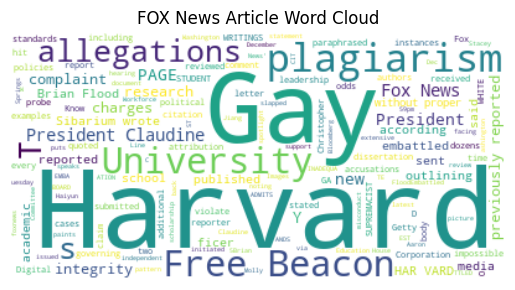

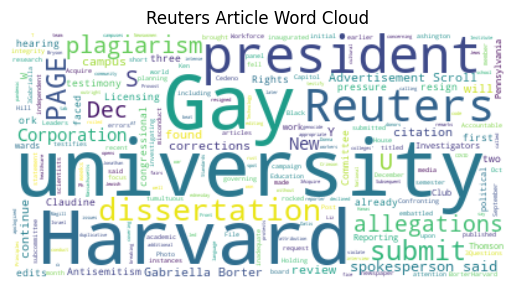

In [10]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# FOX News word cloud
fox_cloud = WordCloud(stopwords=STOPWORDS, background_color='white').generate(fox_text)
plt.imshow(fox_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('FOX News Article Word Cloud')
plt.show()

# Reuters word cloud
reuters_cloud = WordCloud(stopwords=STOPWORDS, background_color='white').generate(reuters_text)
plt.imshow(reuters_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Reuters Article Word Cloud')
plt.show()



Both articles focus on **Harvard**, **Claudine Gay**, and **plagiarism**, but the tone differs.  
The **FOX News** cloud highlights words like *“allegations”* and *“charges”*, showing an emphasis on controversy and accusation.  
The **Reuters** cloud includes words such as *“dissertation”* and *“submit”*, reflecting a more factual, procedural focus.  
Overall, FOX appears more dramatic, while Reuters stays neutral and informational.

